# Projet IFT-4201/7201 — FrozenLake
## Étude de l'impact des dynamiques non-déterministes sur l'évitement des situations dangereuses

Ce notebook sert de point d'entrée : il lance les expériences, charge les résultats et affiche les figures.  
Toute la logique est dans `src/` ; les résultats JSON dans `results/` ; les figures dans `figures/`.

In [1]:
import importlib
import src.plots, src.evaluate
importlib.reload(src.plots)
importlib.reload(src.evaluate)
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.envs    import MAPS, make_env
from src.agents  import q_learning, sarsa
from src.evaluate import evaluate_agent, evaluate_safe_path_rate, safest_path
from src.plots   import (load_results, plot_training_curves, plot_evaluation_results,
                          plot_danger_boxplot, plot_overview, plot_policy_arrows)

COLORS = ['#e30513', '#ffc103', '#0099ff', '#515151',
          '#f7a941', '#51a27e', '#702e78', '#7b003d']


---
## 1. Cas d'étude

### 1.1 Composantes de l'environnement FrozenLake

L'environnement **FrozenLake-v1** (Gymnasium) modélise un lac gelé sur une grille N×N.  
Un joueur part de la case de départ **S** et doit atteindre le cadeau **G** en évitant les trous **H**.  
Avec `is_slippery=True`, l'action choisie est exécutée dans la direction souhaitée avec probabilité 1/3
et dans chacune des deux directions perpendiculaires avec probabilité 1/3 (dynamique non-déterministe).

| Paramètre | Effet sur la difficulté |
|-----------|------------------------|
| `is_slippery` | Degré de stochasticité de la dynamique |
| Nombre de cases `H` | Nombre de situations dangereuses |
| Positionnement des `H` | Proximité avec le chemin optimal |

### 1.2 Reward shaping

| Événement | Récompense |
|-----------|------------|
| Tombe dans un trou `H` | −1.0 |
| Atteint le but `G` | +1.0 |
| Collision avec un mur (bord de grille) | −0.1 |
| Déplacement normal | 0.0 |

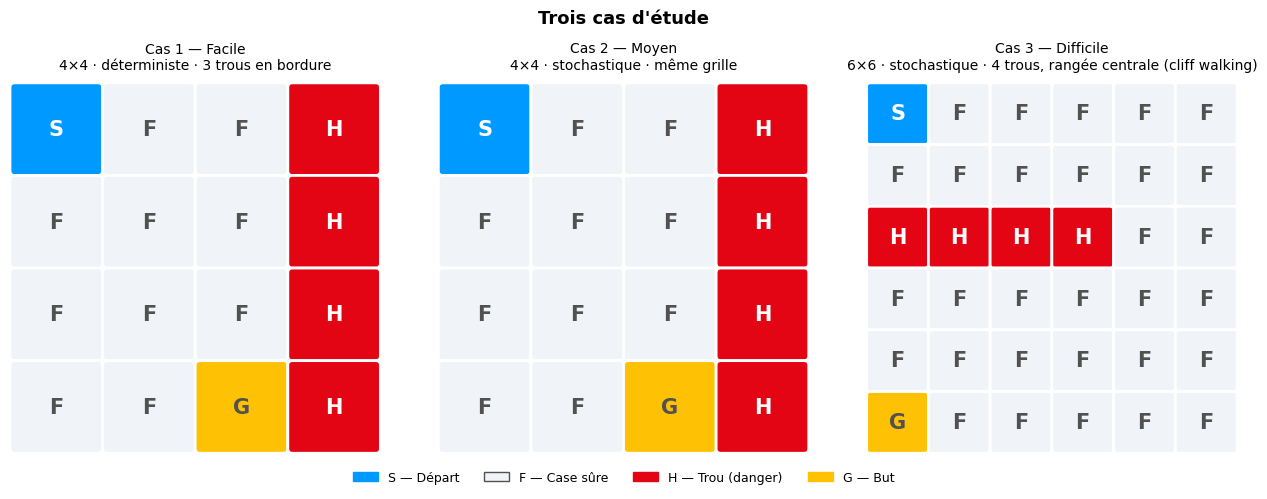

In [2]:
TILE_COLORS = {'S': COLORS[2], 'F': '#f0f4f8', 'H': COLORS[0], 'G': COLORS[1]}
TILE_TEXT   = {'S': 'white',   'F': COLORS[3], 'H': 'white',   'G': COLORS[3]}

titles = [
    "Cas 1 — Facile\n4×4 · déterministe · 3 trous en bordure",
    "Cas 2 — Moyen\n4×4 · stochastique · même grille",
    "Cas 3 — Difficile\n6×6 · stochastique · 4 trous, rangée centrale (cliff walking)",
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (name, cfg), title in zip(axes, MAPS.items(), titles):
    desc = cfg['desc']
    nrow, ncol = len(desc), len(desc[0])
    for r, row in enumerate(desc):
        for c, tile in enumerate(row):
            ax.add_patch(mpatches.FancyBboxPatch(
                (c+0.05, nrow-r-1+0.05), 0.9, 0.9,
                boxstyle='round,pad=0.05',
                facecolor=TILE_COLORS[tile], edgecolor='white', linewidth=2))
            ax.text(c+0.5, nrow-r-0.5, tile, ha='center', va='center',
                    fontsize=15, fontweight='bold', color=TILE_TEXT[tile])
    ax.set_xlim(0, ncol); ax.set_ylim(0, nrow)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=10, pad=10)

legend = [
    mpatches.Patch(color=TILE_COLORS['S'], label='S — Départ'),
    mpatches.Patch(color=TILE_COLORS['F'], label='F — Case sûre', ec=COLORS[3]),
    mpatches.Patch(color=TILE_COLORS['H'], label='H — Trou (danger)'),
    mpatches.Patch(color=TILE_COLORS['G'], label='G — But'),
]
fig.legend(handles=legend, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.06), frameon=False, fontsize=9)
plt.suptitle("Trois cas d'étude", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/maps.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Motivation des trois cas d'étude

| Cas | Grille | `is_slippery` | Trous | Motivation |
|-----|--------|--------------|-------|------------|
| **easy** | 4×4 | `False` | 3, bordure droite | Référence déterministe — isole les difficultés structurelles sans stochasticité. |
| **medium** | 4×4 | `True` | 3, bordure droite | **Isole l'effet de la stochasticité** — seul `is_slippery` change. |
| **hard** | 6×6 | `True` | 4, rangée centrale | Combine stochasticité et positionnement hostile : la rangée HHHHFF crée une barrière analogue au *cliff walking* (Sutton & Barto, 2018). |

---
## 2. Stratégies considérées

Deux algorithmes TD(0) tabulaires *baselines* — sans mécanisme explicite d'évitement de danger.

### Q-learning (off-policy)
$$Q(s,a) \leftarrow Q(s,a) + \alpha_t\left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]$$
Optimiste : la mise à jour ignore le risque lié à l'exploration.

### SARSA (on-policy)
$$Q(s,a) \leftarrow Q(s,a) + \alpha_t\left[r + \gamma Q(s', a') - Q(s,a)\right]$$
Conservateur : met à jour avec l'action réellement choisie, naturellement plus prudent près des trous (cf. *cliff walking*, Sutton & Barto, 2018).

### Politique d'exploration : ε-greedy avec décroissance exponentielle
$$\varepsilon_t = \max(\varepsilon_{\min},\ \varepsilon_0 \cdot d^{\,t}), \quad \alpha_t = \max(\alpha_{\min},\ \alpha_0 \cdot d^{\,t})$$
avec $\varepsilon_0=1$, $\varepsilon_{\min}=0.05$, $\alpha_0=0.5$, $\alpha_{\min}=0.01$, $d=0.9995$.

---
## 3. Méthodologie expérimentale

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| γ | 0.99 | Valorise les récompenses à long terme |
| α₀ / α_min | 0.5 / 0.01 | Apprentissage rapide puis stabilisation |
| Épisodes | 20 000 | Convergence observée avant 15 000 |
| Répétitions | 10 | Intervalles de confiance (mean ± std) |

**Indicateurs de performance :**
- *Durant l'apprentissage* : récompense et taux de chutes par épisode (fenêtre glissante = 500)
- *Évaluation finale* (politique greedy, 500 épisodes) : taux de succès, boucles (timeouts), états dangereux, chemins sécurisés (Dijkstra)

In [3]:
#!python run_experiments.py --config config/config_baselines.yaml

---
## 4. Résultats

In [4]:
experiments = load_results('results')

  qlearning_easy  (10 runs, Q=oui)
  qlearning_hard  (10 runs, Q=oui)
  qlearning_medium  (10 runs, Q=oui)
  sarsa_easy  (10 runs, Q=oui)
  sarsa_hard  (10 runs, Q=oui)
  sarsa_medium  (10 runs, Q=oui)


In [5]:
plot_training_curves(experiments, env_names=['easy', 'medium', 'hard'], save_dir='figures', window=500)

Sauvegardé : figures/training_easy.png
Sauvegardé : figures/training_medium.png
Sauvegardé : figures/training_hard.png


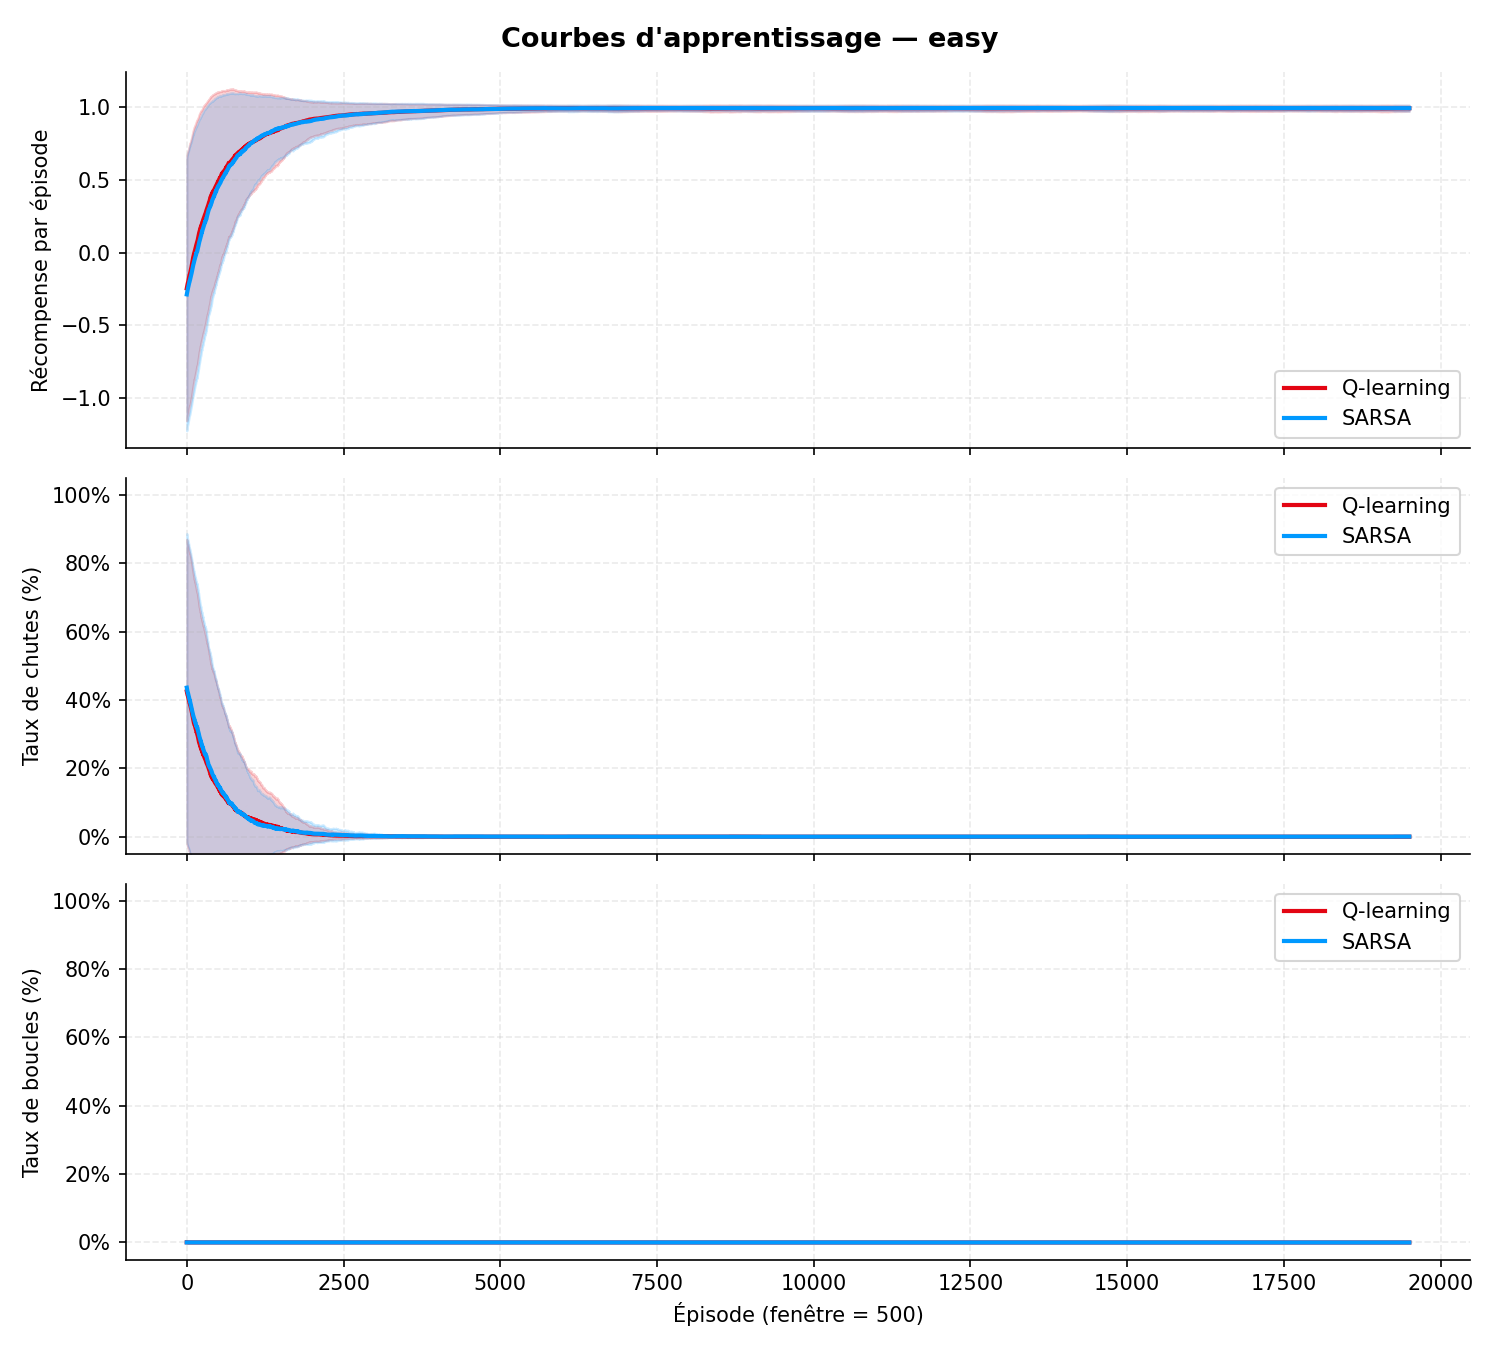

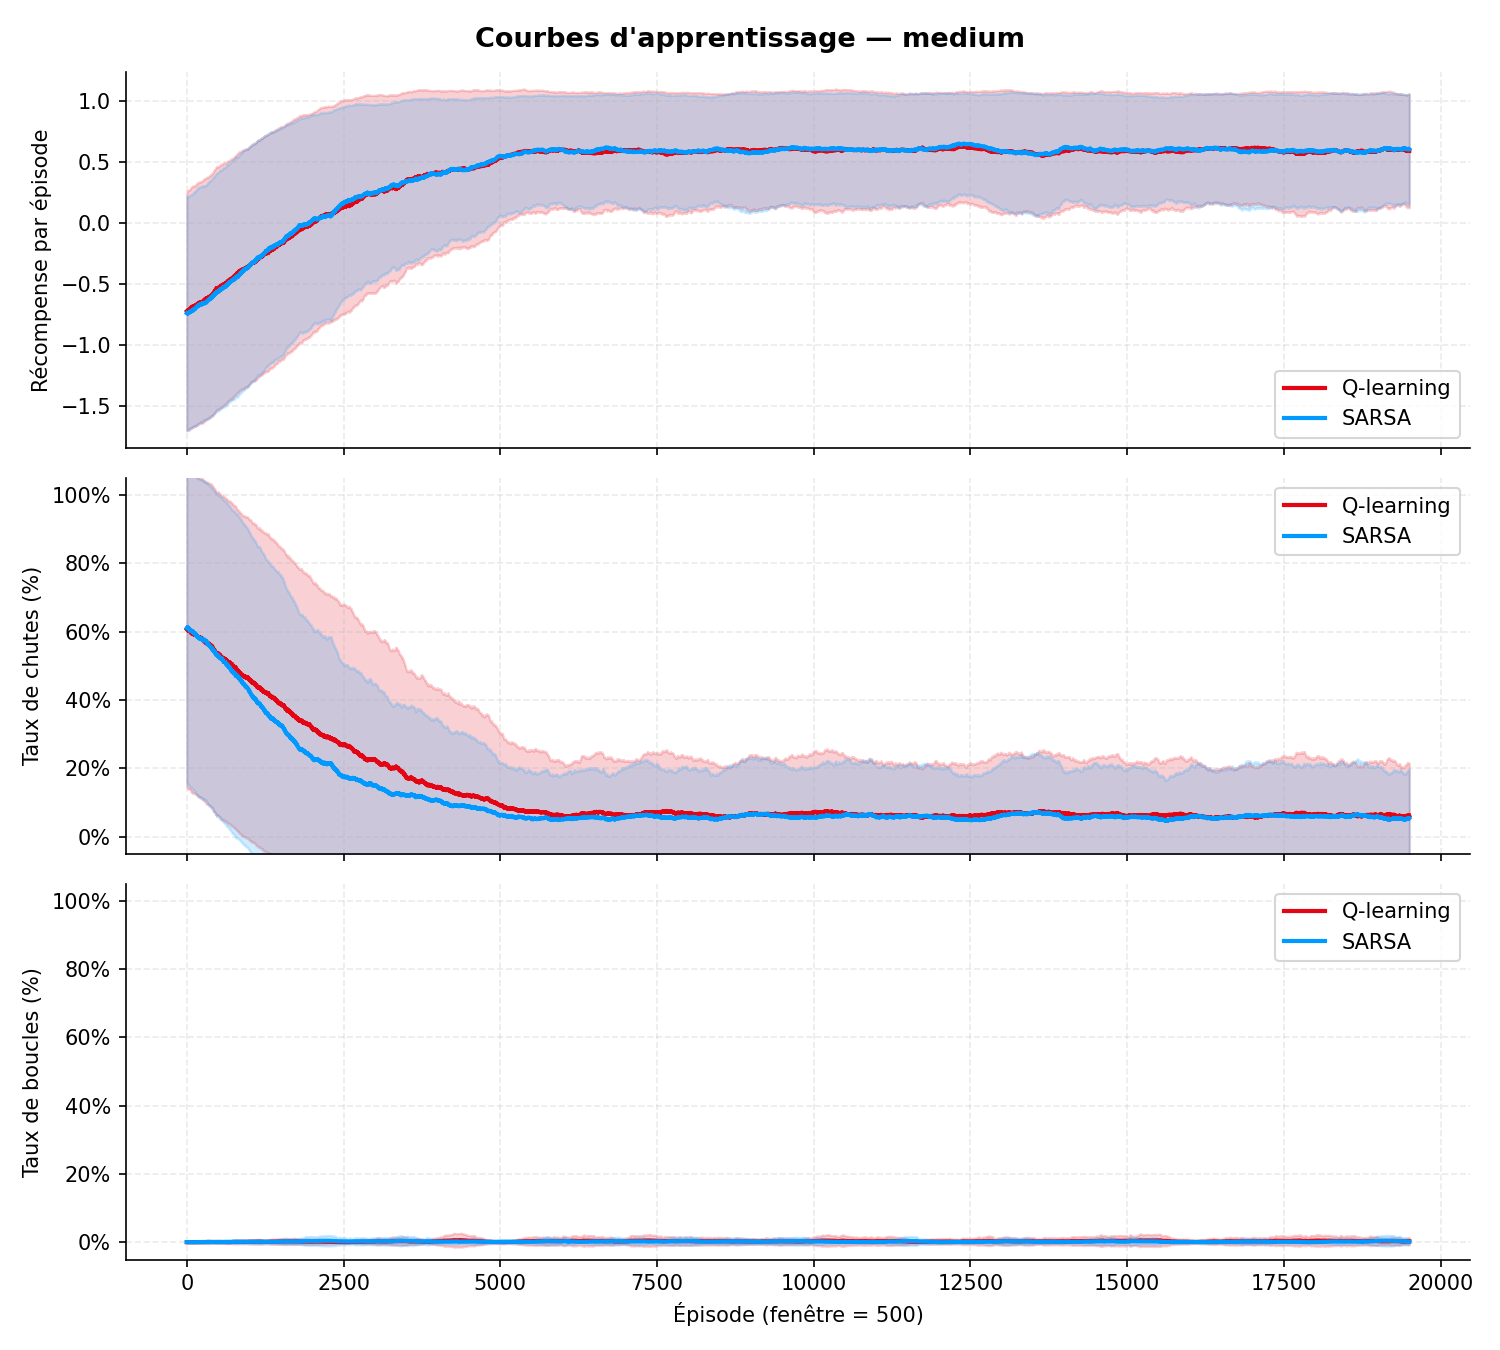

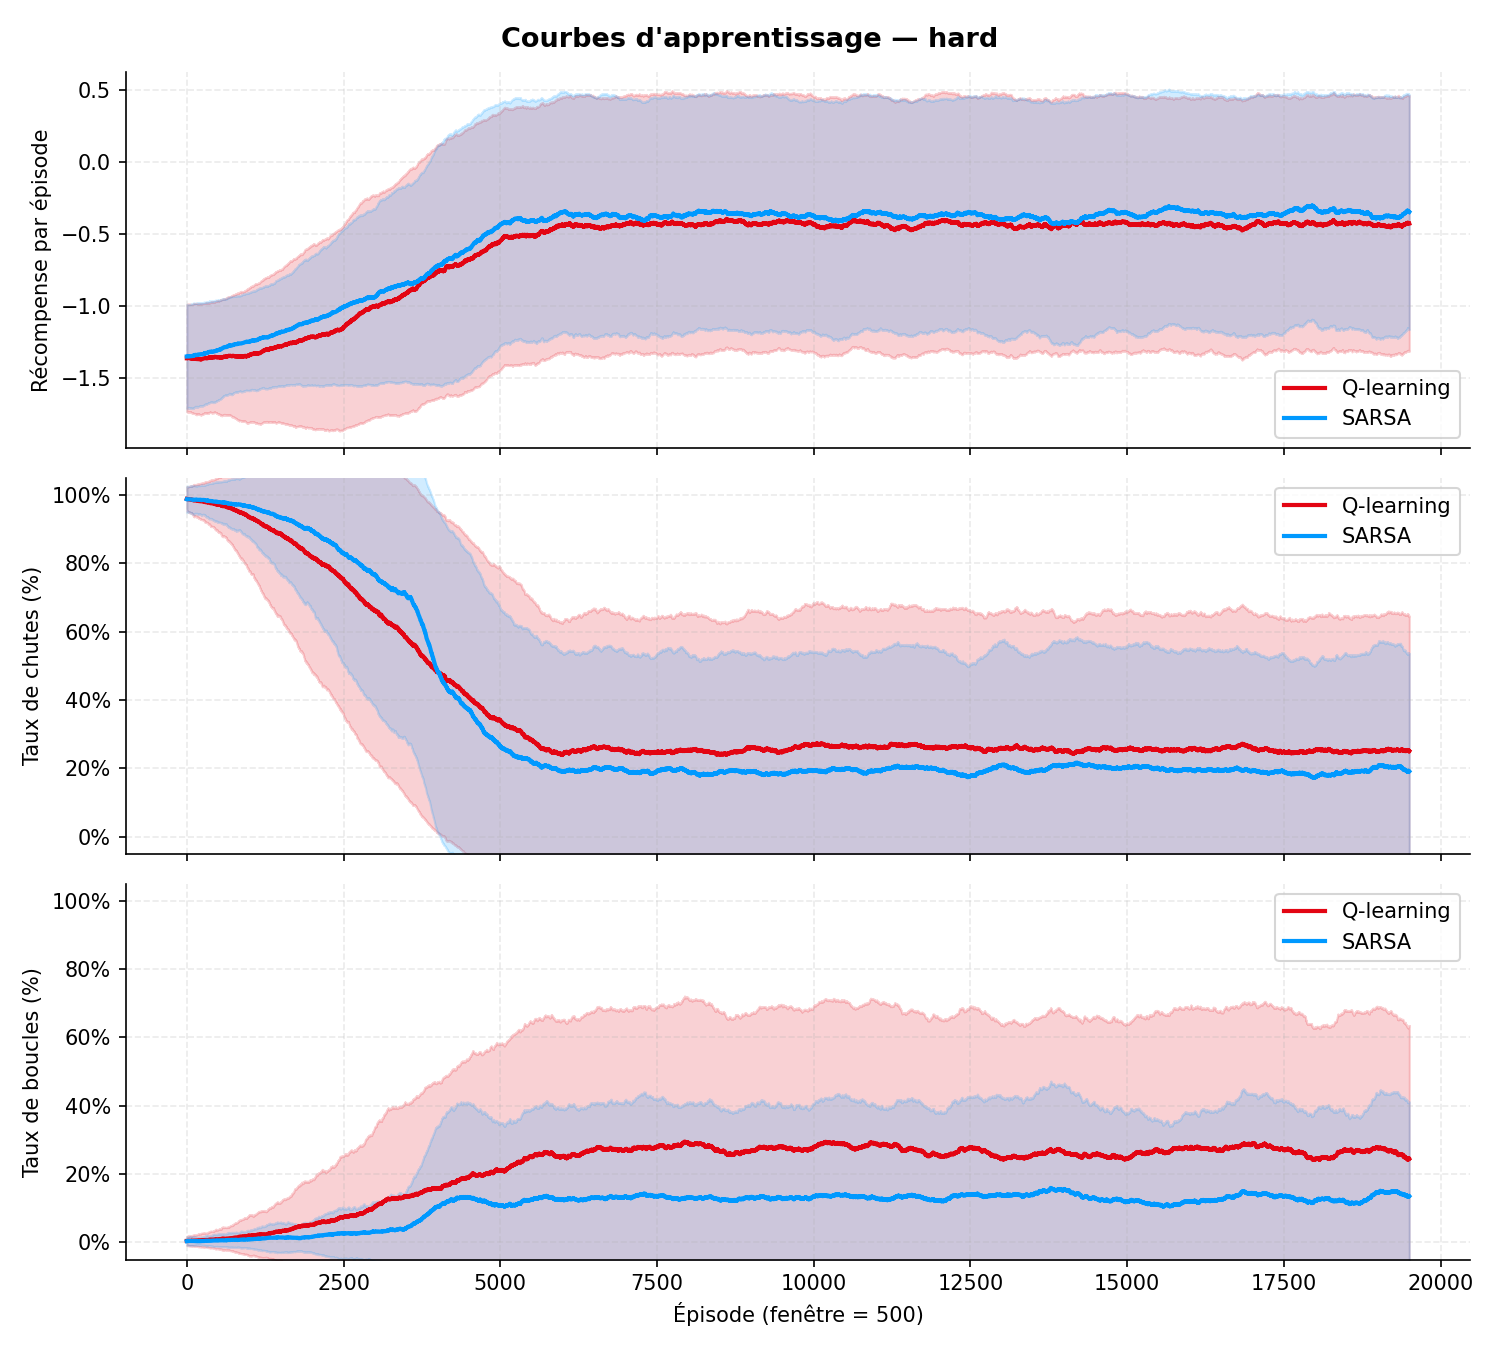

In [6]:
from IPython.display import Image, display
display(Image('figures/training_easy.png'))
display(Image('figures/training_medium.png'))
display(Image('figures/training_hard.png'))

In [7]:
plot_evaluation_results(experiments, save_dir='figures')

Sauvegardé : figures/evaluation_easy.png
Sauvegardé : figures/evaluation_hard.png
Sauvegardé : figures/evaluation_medium.png


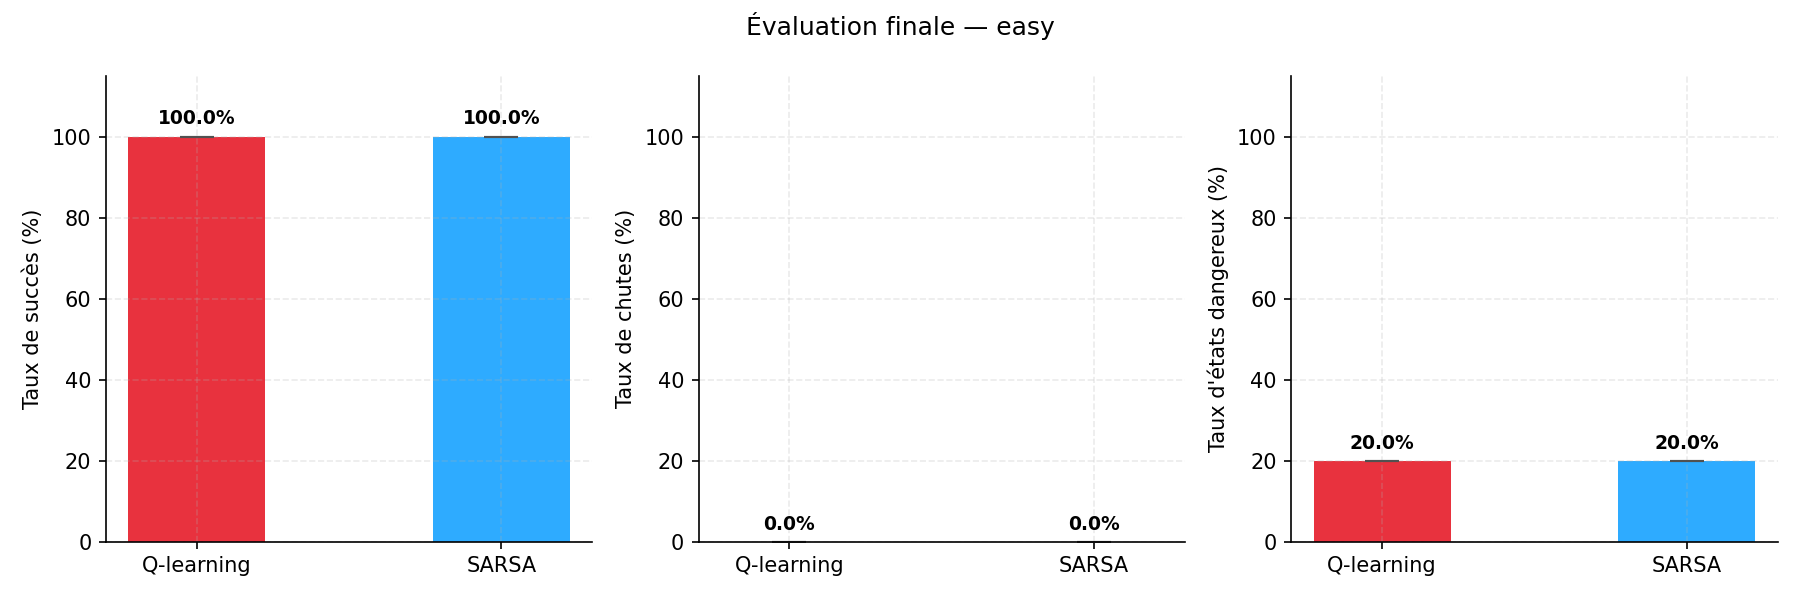

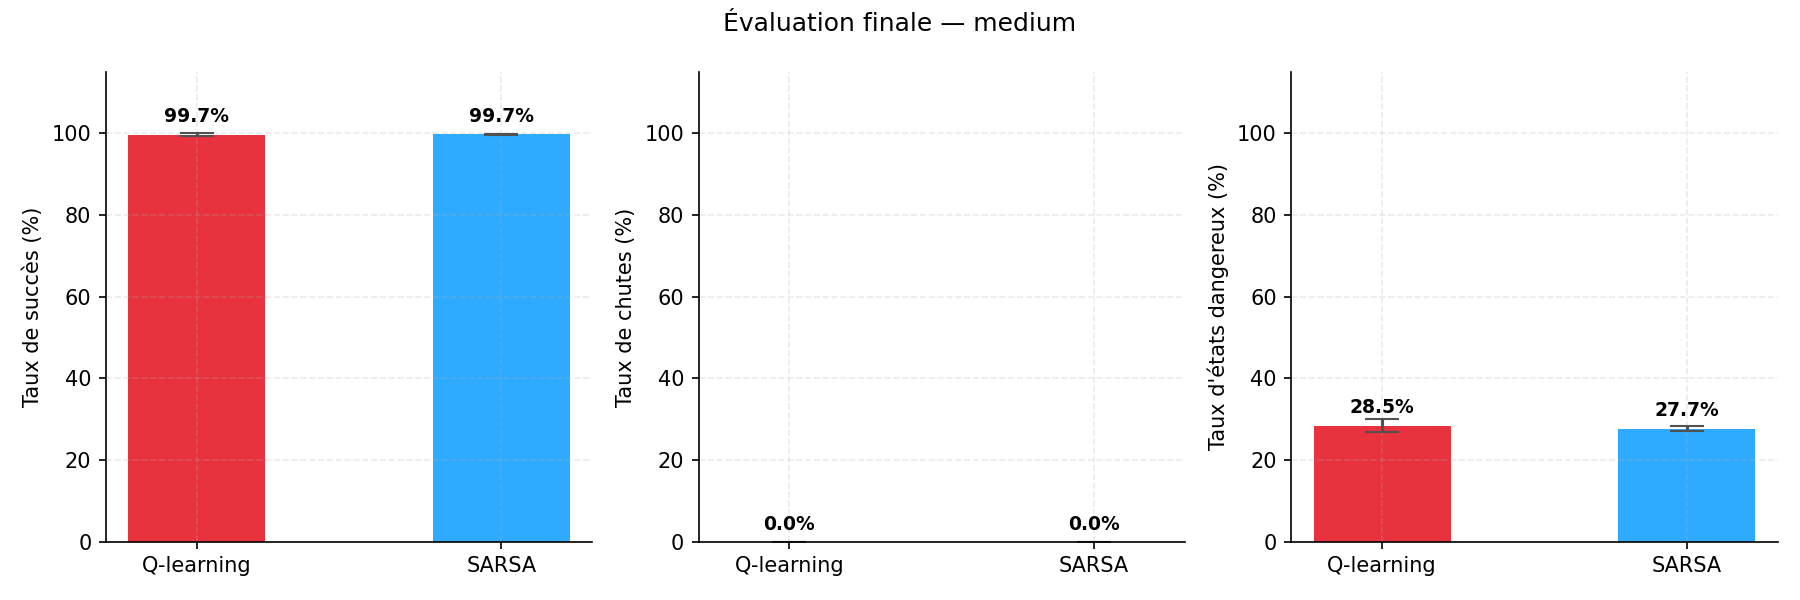

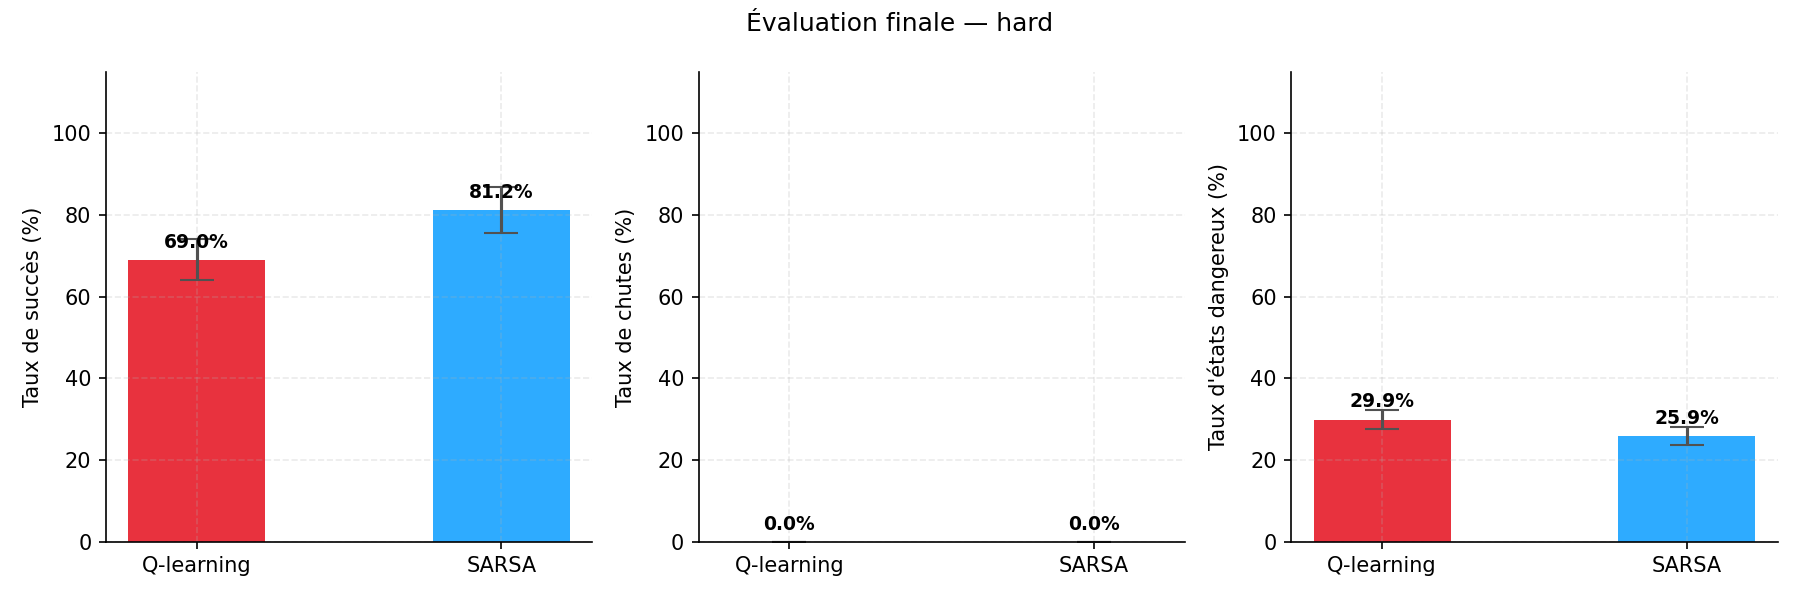

In [8]:
display(Image('figures/evaluation_easy.png'))
display(Image('figures/evaluation_medium.png'))
display(Image('figures/evaluation_hard.png'))

In [9]:
plot_overview(experiments, save_dir='figures')

Sauvegardé : figures/overview_success_rate.png
Sauvegardé : figures/overview_fall_rate.png


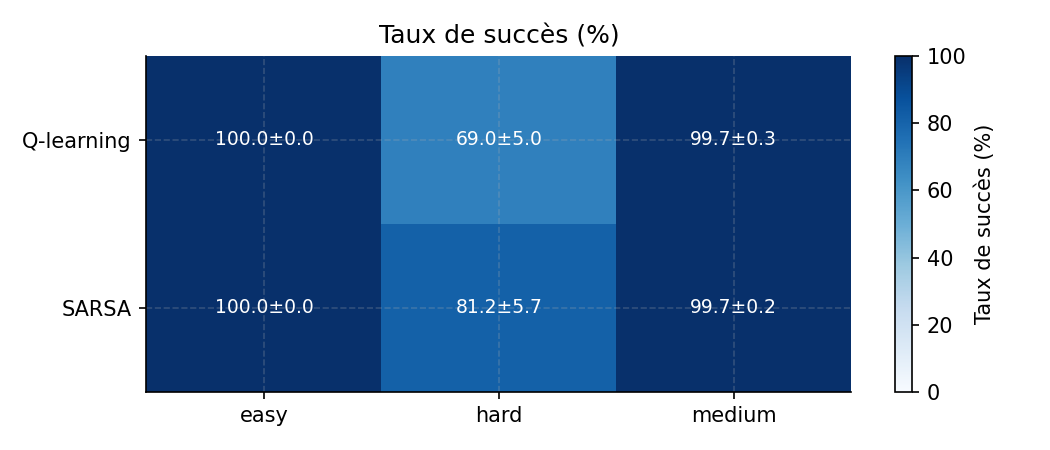

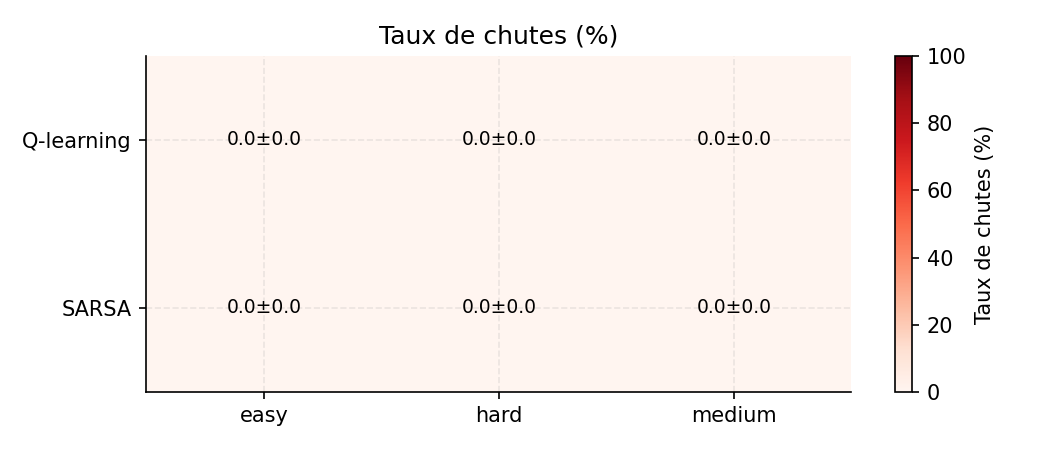

In [10]:
display(Image('figures/overview_success_rate.png'))
display(Image('figures/overview_fall_rate.png'))

In [11]:
plot_danger_boxplot(experiments, save_dir='figures')

Sauvegardé : figures/danger_boxplot.png


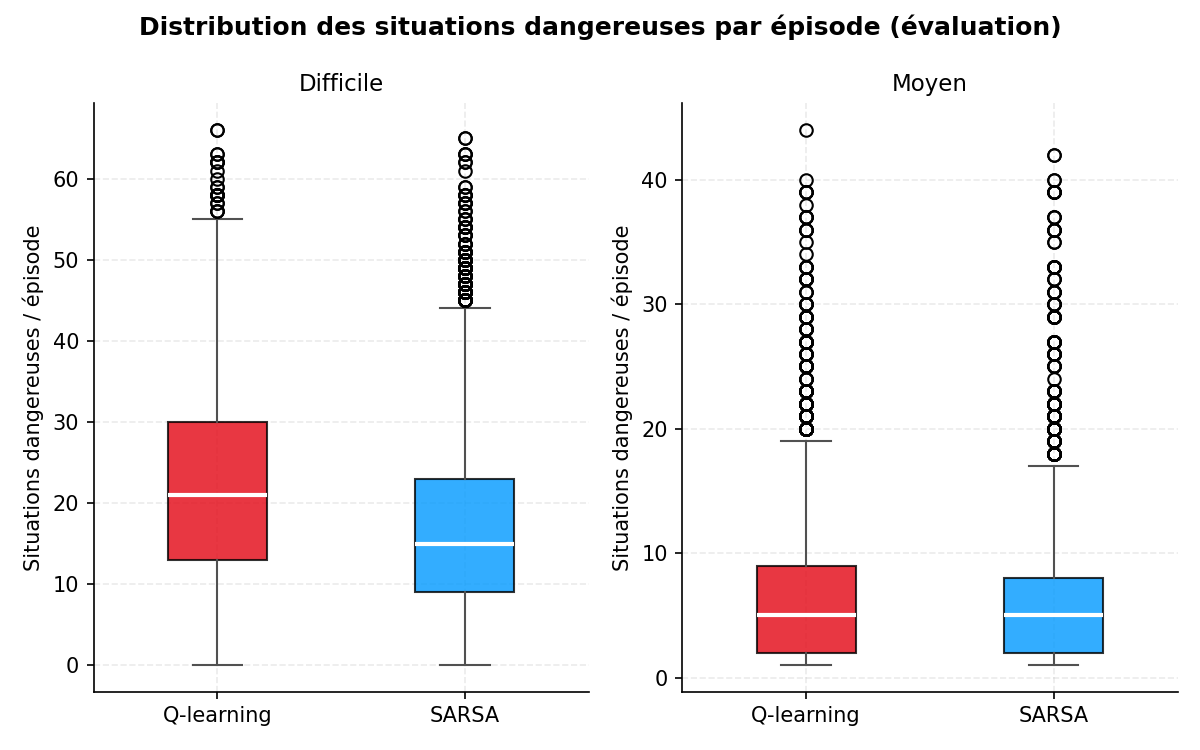

In [12]:
display(Image('figures/danger_boxplot.png'))

### 4.5 Visualisation des politiques apprises (flèches greedy + chemin Dijkstra)


In [13]:
plot_policy_arrows(experiments, env_names=['easy', 'medium', 'hard'], save_dir='figures')


Sauvegardé : figures/policy_easy.png
Sauvegardé : figures/policy_medium.png
Sauvegardé : figures/policy_hard.png


=== Politique greedy — Facile ===


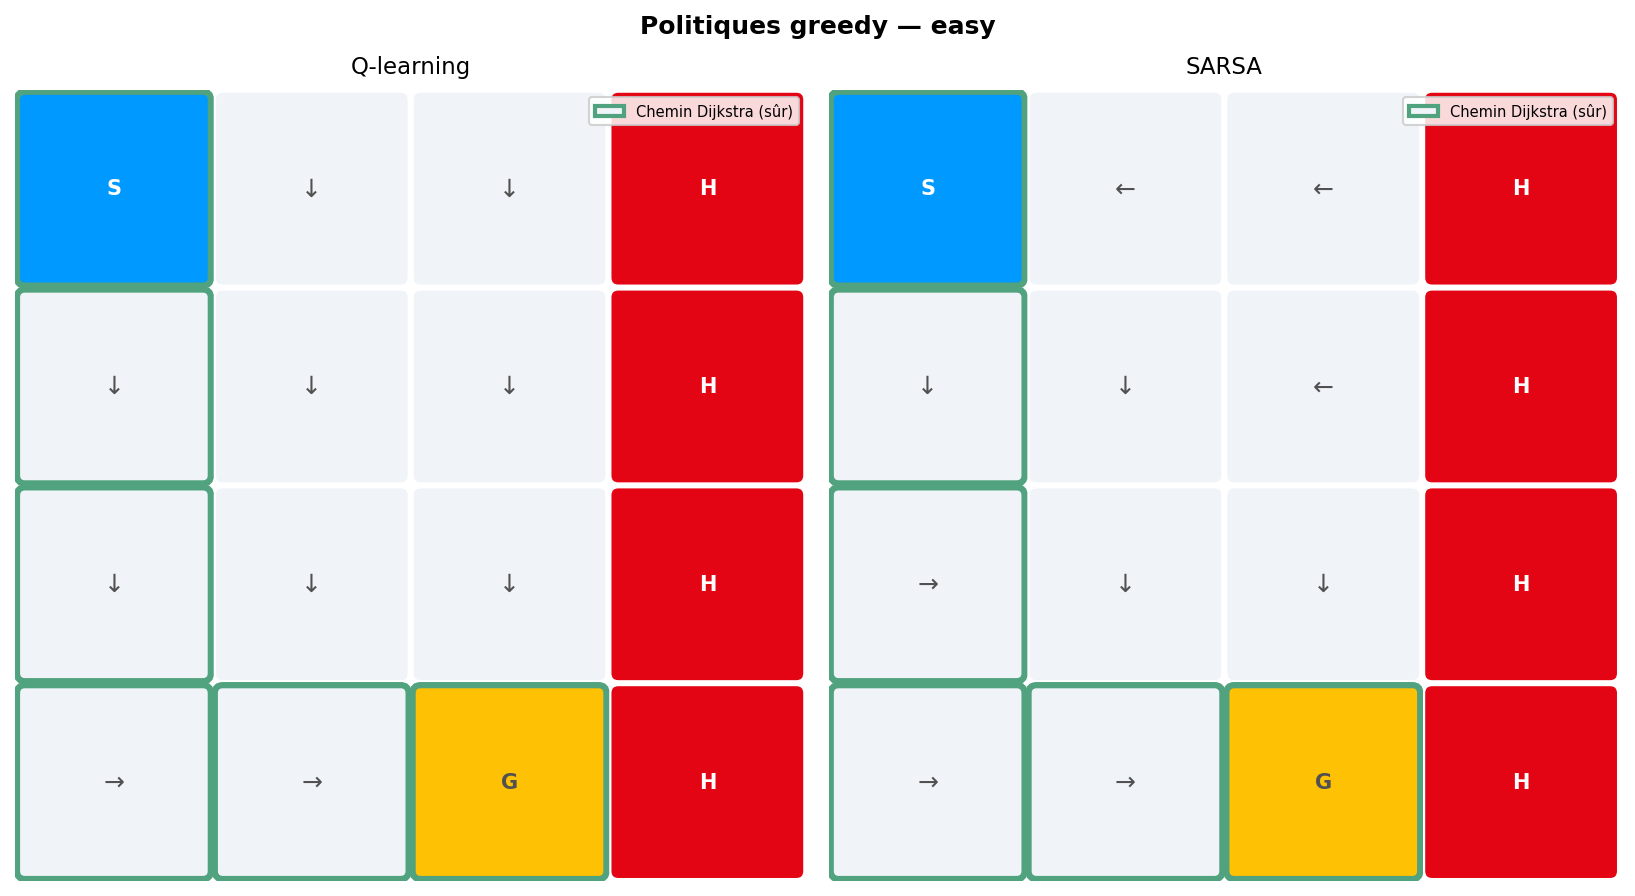

=== Politique greedy — Moyen ===


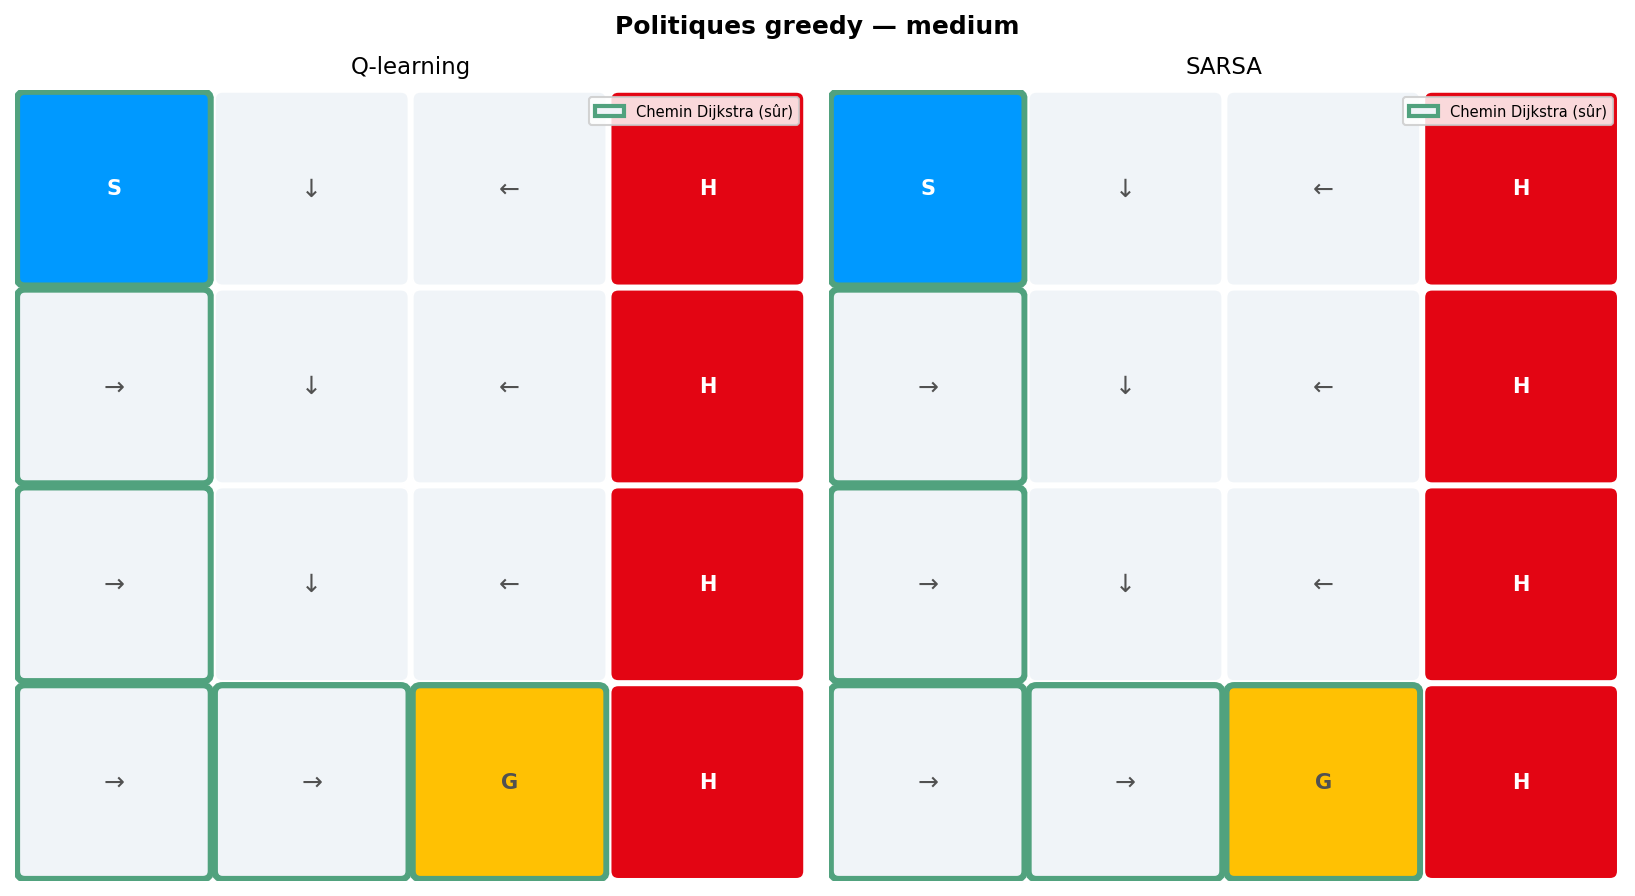

=== Politique greedy — Difficile ===


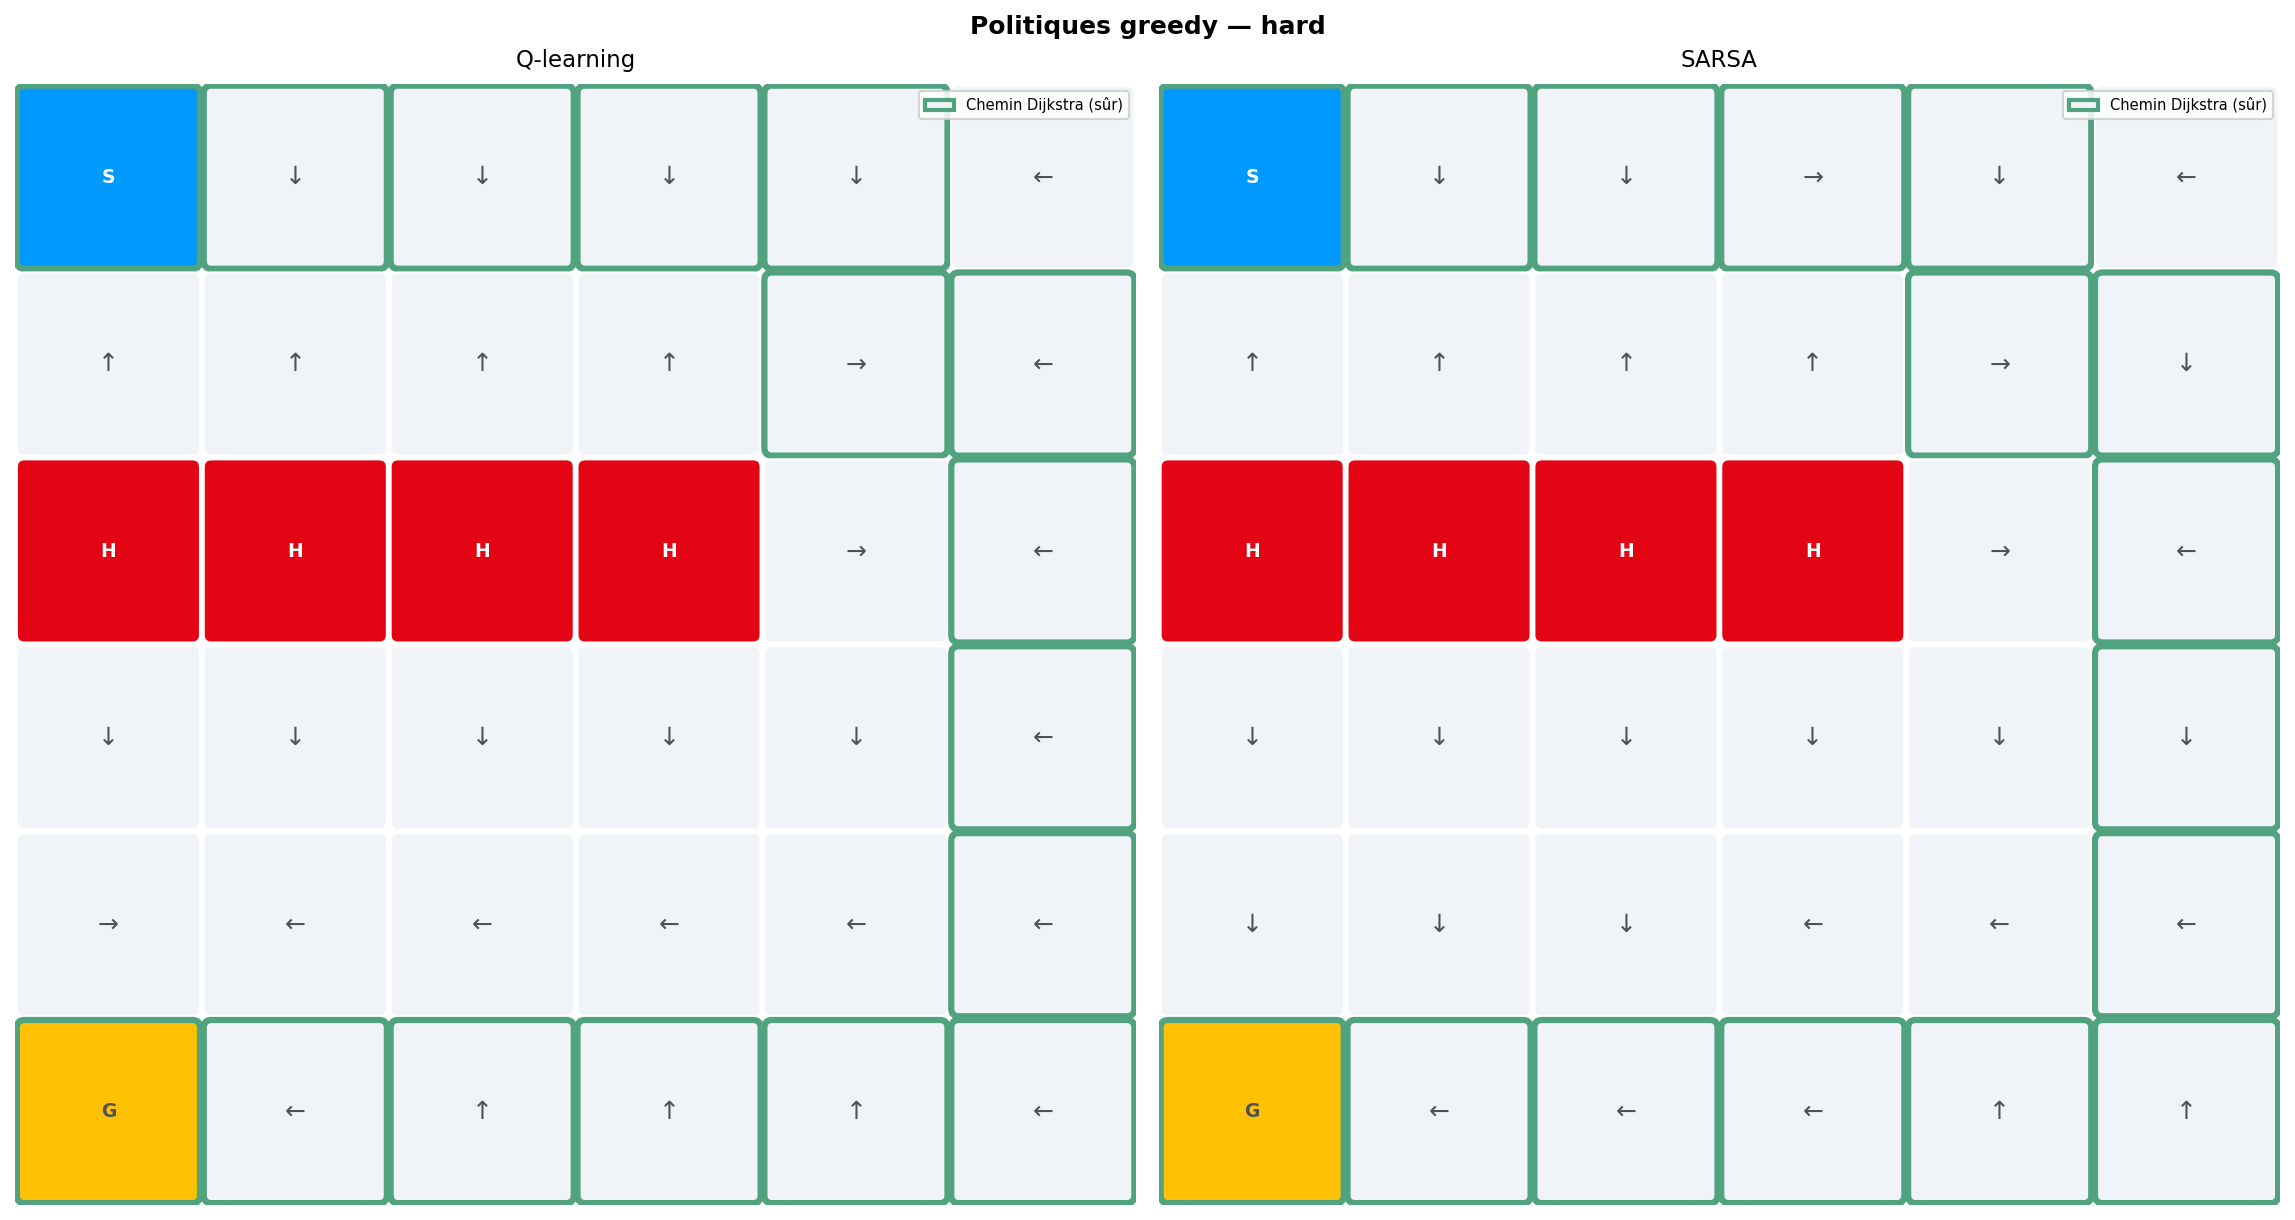

In [14]:
from IPython.display import Image, display
print("=== Politique greedy — Facile ===")
display(Image('figures/policy_easy.png'))
print("=== Politique greedy — Moyen ===")
display(Image('figures/policy_medium.png'))
print("=== Politique greedy — Difficile ===")
display(Image('figures/policy_hard.png'))


In [15]:
# Taux de chemins sécurisés sur le cas Difficile (Dijkstra)
print(f"{'Expérience':<22} {'Chemin sécurisé':>18}")
print('─' * 42)
for algo in ['qlearning', 'sarsa']:
    exp_name = f'{algo}_hard'
    rates = [e['safe_path_rate'] for e in experiments[exp_name]['evaluation']
             if 'safe_path_rate' in e]
    if rates:
        m, s = np.mean(rates)*100, np.std(rates)*100
        print(f"{exp_name:<22} {m:>5.1f} ± {s:<4.1f}%")

Expérience                Chemin sécurisé
──────────────────────────────────────────
qlearning_hard          60.1 ± 2.9 %
sarsa_hard              70.4 ± 2.9 %


In [16]:
print(f"{'Expérience':<24} {'Succès':>12} {'Boucles':>12} {'Danger':>10}")
print('─' * 64)
for exp_name, data in sorted(experiments.items()):
    sr = np.mean([e['success_rate']  for e in data['evaluation']]) * 100
    tr = np.mean([e['timeout_rate']  for e in data['evaluation']]) * 100
    dr = np.mean([e['danger_rate']   for e in data['evaluation']]) * 100
    ss = np.std ([e['success_rate']  for e in data['evaluation']]) * 100
    ts = np.std ([e['timeout_rate']  for e in data['evaluation']]) * 100
    print(f"{exp_name:<24} {sr:>5.1f}±{ss:<4.1f}%  {tr:>5.1f}±{ts:<4.1f}%  {dr:>6.1f}%")

Expérience                     Succès      Boucles     Danger
────────────────────────────────────────────────────────────────
qlearning_easy           100.0±0.0 %    0.0±0.0 %    20.0%
qlearning_hard            69.0±5.0 %   31.0±5.0 %    29.9%
qlearning_medium          99.7±0.3 %    0.3±0.3 %    28.5%
sarsa_easy               100.0±0.0 %    0.0±0.0 %    20.0%
sarsa_hard                81.2±5.7 %   18.8±5.7 %    25.9%
sarsa_medium              99.7±0.2 %    0.3±0.2 %    27.7%


---
## 5. Bibliographie

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8, 279–292.
- Rummery, G. A., & Niranjan, M. (1994). *On-line Q-learning using connectionist systems*. Technical Report, Cambridge University.
- Mnih, V., et al. (2015). Human-level control through deep reinforcement learning. *Nature*, 518, 529–533.
- Dijkstra, E. W. (1959). A note on two problems in connexion with graphs. *Numerische Mathematik*, 1, 269–271.
- Towers, M., et al. (2024). Gymnasium: A standard interface for reinforcement learning environments. *arXiv:2407.17032*.